# Concept 53 – Agent-to-Agent (A2A) Protocol with LangGraph

This notebook is a step-by-step teaching demo for the **A2A protocol** — an open standard that lets AI agents talk to other AI agents over HTTP.

---

## What is A2A?

**A2A (Agent-to-Agent)** is an open protocol (published by Google, April 2025) that defines a standard HTTP interface so that one AI agent can discover, communicate with, and delegate tasks to another AI agent — regardless of which framework or vendor built each agent.

### A2A vs MCP — what is the difference?

| | MCP (Model Context Protocol) | A2A (Agent-to-Agent) |
|---|---|---|
| **What connects** | Agent ↔ Tools / Resources / Prompts | Agent ↔ Agent |
| **The remote side is** | A dumb function (no reasoning) | A full agent (has its own LLM, tools, memory) |
| **Transport** | stdio subprocess | HTTP / SSE |
| **Discovery** | `get_tools()` call | `GET /.well-known/agent.json` (Agent Card) |
| **Use when** | Agent needs a tool to do one specific thing | Agent needs to delegate a whole sub-task to a specialist agent |

### A2A core concepts

| Concept | Description |
|---|---|
| **Agent Card** | A JSON document at `/.well-known/agent.json` that describes the agent: name, skills, capabilities, URL |
| **Skill** | A declared capability of the agent (e.g. "course search", "learning advisor") |
| **Message** | A single turn of communication — contains a `role` (`user` or `agent`) and one or more `parts` |
| **Part** | The content inside a message — usually `{"type": "text", "text": "..."}` |
| **`/messages/send`** | The core A2A endpoint — client sends a message, agent responds with a message |

### Architecture of this demo

```
User question
    -> LangGraph Orchestrator Agent  (Claude Haiku, this notebook)
        -> ask_course_advisor tool
            -> HTTP POST /messages/send
                -> Course Advisor A2A Agent  (FastAPI server, localhost:8765)
                    -> rule-based advisor logic
                <- HTTP 200 { "result": { "parts": [{"text": "..."}] } }
        <- tool result
    <- final answer to user
```

## Step 1 – Install Required Packages

- `fastapi` + `uvicorn` — used to build the A2A server (the HTTP server that hosts our agent)
- `httpx` — async HTTP client used to call the A2A server from the orchestrator
- `langchain-anthropic` — LangChain wrapper for Claude models (the orchestrator LLM)

In [1]:
%pip install -q fastapi uvicorn httpx langchain-anthropic


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 2 – Create the A2A Agent Server

`%%writefile` saves the code below to `a2a_course_agent_server.py`.
We will launch this file as a background process in Step 3.

This server implements **two A2A HTTP endpoints**:

| Endpoint | Method | Purpose |
|---|---|---|
| `/.well-known/agent.json` | `GET` | Returns the **Agent Card** — lets any client discover what this agent can do |
| `/messages/send` | `POST` | Receives a **Message** from a client, processes it, returns a response **Message** |

The agent itself is intentionally **rule-based** (no LLM inside the worker agent).  
This is a teaching choice — it lets you focus on the A2A protocol without additional API calls.

In [2]:
%%writefile a2a_course_agent_server.py
"""
A2A-compliant Course Advisor Agent.

Implements the two mandatory A2A HTTP endpoints:
  GET  /.well-known/agent.json   ->  Agent Card (capability manifest)
  POST /messages/send            ->  Receive a message, return a response
"""
import json
import uuid
import uvicorn
from fastapi import FastAPI, Request

app = FastAPI(title="Course Advisor A2A Agent")


# ── Course Catalog ─────────────────────────────────────────────────────────────
# The agent's knowledge base. In a real agent this would query a database.
COURSES = {
    "lg-101": {
        "title": "LangGraph Fundamentals",
        "level": "beginner",
        "duration_weeks": 2,
        "topics": ["state graph", "nodes", "edges", "tool calling"],
    },
    "mcp-101": {
        "title": "Model Context Protocol Basics",
        "level": "beginner",
        "duration_weeks": 1,
        "topics": ["mcp server", "mcp client", "tools", "resources"],
    },
    "a2a-201": {
        "title": "Agent-to-Agent Communication",
        "level": "intermediate",
        "duration_weeks": 2,
        "topics": ["a2a protocol", "agent cards", "multi-agent", "orchestration"],
    },
    "agent-301": {
        "title": "Agentic AI with LangGraph",
        "level": "advanced",
        "duration_weeks": 4,
        "topics": ["react agent", "multi-agent", "memory", "human feedback"],
    },
}


def search_courses(query: str) -> list[dict]:
    """Return courses whose fields contain the query string."""
    q = query.lower()
    return [
        {"course_id": cid, **c}
        for cid, c in COURSES.items()
        if q in json.dumps(c).lower() or q in cid
    ]


def build_reply(user_text: str) -> str:
    """
    Rule-based advisor logic — the 'intelligence' of this worker agent.
    No LLM required; the point is to demonstrate A2A, not agent reasoning.
    """
    msg = user_text.lower()

    # --- Beginner / starting-point questions ---
    if any(w in msg for w in ["beginner", "start", "new to", "introduction", "first"]):
        beginner_courses = [c for c in COURSES.values() if c["level"] == "beginner"]
        names = ", ".join(c["title"] for c in beginner_courses)
        return (
            f"For beginners I recommend: {names}. "
            "Start with LangGraph Fundamentals (2 weeks) then add MCP Basics (1 week) "
            "before moving to intermediate topics."
        )

    # --- Search / find / list questions ---
    if any(w in msg for w in ["search", "find", "show", "list", "what courses"]):
        results = []
        for word in msg.split():
            if len(word) > 3:           # skip short words like 'the', 'and'
                results.extend(search_courses(word))
        unique = {r["course_id"]: r for r in results}
        if unique:
            lines = [
                f"  - {r['title']} [{r['level']}, {r['duration_weeks']} weeks]"
                for r in unique.values()
            ]
            return "Found {}  course(s):\n".format(len(unique)) + "\n".join(lines)
        return (
            "No courses matched your query. "
            "Available topics: LangGraph, MCP, A2A, multi-agent, memory."
        )

    # --- Duration / time estimate questions ---
    if any(w in msg for w in ["time", "hour", "duration", "long", "weeks"]):
        total_weeks = sum(c["duration_weeks"] for c in COURSES.values())
        # Try to extract hours_per_week from the message (look for a number before 'hour')
        import re
        match = re.search(r"(\d+)\s*hour", msg)
        hours_per_week = int(match.group(1)) if match else 6
        total_hours = total_weeks * hours_per_week
        return (
            f"The full curriculum spans {total_weeks} weeks. "
            f"At {hours_per_week} hours/week that is {total_hours} total hours. "
            "Individual courses: LangGraph (2w), MCP (1w), A2A (2w), Agentic AI (4w)."
        )

    # --- A2A-specific questions ---
    if "a2a" in msg or "agent to agent" in msg or "agent-to-agent" in msg:
        c = COURSES["a2a-201"]
        return (
            f"For A2A I recommend: '{c['title']}' ({c['level']}, {c['duration_weeks']} weeks). "
            f"Topics covered: {', '.join(c['topics'])}."
        )

    # --- Default: full catalog summary ---
    lines = [
        f"  - [{cid}] {c['title']} ({c['level']}, {c['duration_weeks']}w)"
        for cid, c in COURSES.items()
    ]
    return "Full course catalog:\n" + "\n".join(lines)


# ── A2A Endpoint 1: Agent Card ─────────────────────────────────────────────────
@app.get("/.well-known/agent.json")
def get_agent_card():
    """
    The Agent Card is the A2A equivalent of an OpenAPI spec.
    Every A2A client fetches this first to learn:
      - What the agent is called and what it does
      - Which skills it exposes
      - Which input/output modes it supports (text, file, data)
      - Whether it supports streaming or push notifications
    """
    return {
        "name": "Course Advisor Agent",
        "description": (
            "A specialist agent that searches the AI course catalog, "
            "recommends learning paths, and estimates study time."
        ),
        "url": "http://localhost:8765",
        "version": "1.0.0",
        "defaultInputModes": ["text"],
        "defaultOutputModes": ["text"],
        "capabilities": {
            "streaming": False,          # this agent only does request-response
            "pushNotifications": False,  # no webhook callbacks
        },
        "skills": [
            {
                "id": "course_search",
                "name": "Course Search",
                "description": "Search and filter courses by topic, level, or keyword.",
                "inputModes": ["text"],
                "outputModes": ["text"],
                "examples": [
                    "Find beginner courses",
                    "Show me A2A courses",
                    "List all intermediate courses",
                ],
            },
            {
                "id": "learning_advisor",
                "name": "Learning Advisor",
                "description": "Recommend a personalised learning path and estimate total study time.",
                "inputModes": ["text"],
                "outputModes": ["text"],
                "examples": [
                    "I am a beginner, where do I start?",
                    "How many hours will the full curriculum take at 6 hours per week?",
                ],
            },
        ],
    }


# ── A2A Endpoint 2: Receive and Handle a Message ───────────────────────────────
@app.post("/messages/send")
async def send_message(request: Request):
    """
    Core A2A endpoint.

    Request body shape:
      {
        "message": {
          "role": "user",
          "messageId": "<uuid>",
          "taskId": "<uuid>",       # optional — groups messages into a task
          "contextId": "<uuid>",    # optional — groups tasks into a session
          "parts": [
            { "type": "text", "text": "Find me beginner courses" }
          ]
        }
      }

    Response body shape:
      {
        "result": {
          "role": "agent",
          "messageId": "<uuid>",
          "taskId": "<same uuid>",
          "contextId": "<same uuid>",
          "parts": [
            { "type": "text", "text": "For beginners I recommend..." }
          ]
        }
      }
    """
    body = await request.json()

    # --- Extract user text from the A2A message structure ---
    incoming_message = body.get("message", {})
    parts = incoming_message.get("parts", [])
    user_text = ""
    for part in parts:
        # A part is {"type": "text", "text": "..."} or just {"text": "..."}
        if part.get("type") == "text" or "text" in part:
            user_text = part.get("text", "")
            break

    # --- Run the agent's logic ---
    reply_text = build_reply(user_text)

    # --- Return a properly structured A2A response ---
    # The response re-uses taskId and contextId from the request so the client
    # can correlate the reply back to the original task/session.
    return {
        "result": {
            "role": "agent",
            "messageId": str(uuid.uuid4()),
            "taskId": incoming_message.get("taskId", str(uuid.uuid4())),
            "contextId": incoming_message.get("contextId", str(uuid.uuid4())),
            "parts": [
                {"type": "text", "text": reply_text}
            ],
        }
    }


if __name__ == "__main__":
    # log_level="warning" suppresses uvicorn's per-request access logs
    # so the notebook output stays clean.
    uvicorn.run(app, host="0.0.0.0", port=8765, log_level="warning")


Writing a2a_course_agent_server.py


## Step 3 – Start the A2A Server

We launch the server as a **background subprocess** so it runs independently of the notebook's Python kernel.
The notebook then polls the Agent Card endpoint until the server is ready before continuing.

> **Note:** If you re-run this cell, run the **Cleanup cell (Step 8) first** to avoid a port-already-in-use error.

In [3]:
import subprocess
import sys
import time
import httpx

A2A_SERVER_URL = "http://localhost:8765"

# Launch the A2A server script as a detached subprocess.
# stdout/stderr are suppressed so uvicorn logs don't clutter the notebook.
server_process = subprocess.Popen(
    [sys.executable, "a2a_course_agent_server.py"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)

# Poll the Agent Card endpoint until the server responds (max 10 seconds).
# This is the A2A equivalent of a health check.
print("Starting A2A server ", end="", flush=True)
for _ in range(20):
    try:
        r = httpx.get(f"{A2A_SERVER_URL}/.well-known/agent.json", timeout=1)
        if r.status_code == 200:
            print(" ready!")
            break
    except Exception:
        pass
    time.sleep(0.5)
    print(".", end="", flush=True)
else:
    print(" FAILED — check that port 8765 is free and rerun.")

print(f"Server PID: {server_process.pid}")

Starting A2A server ..... ready!
Server PID: 51246


## Step 4 – Inspect the Agent Card

The **Agent Card** is the heart of A2A discovery.  
Any A2A-compatible orchestrator fetches `GET /.well-known/agent.json` first to learn:
- What the agent is and what it can do
- Which **skills** it exposes (with examples the LLM can read)
- Which input/output modes it supports
- Whether it supports streaming

This is analogous to fetching an OpenAPI spec before calling a REST API.

In [4]:
import json

# Fetch the Agent Card — the A2A capability manifest
async with httpx.AsyncClient() as client:
    response = await client.get(f"{A2A_SERVER_URL}/.well-known/agent.json")
    agent_card = response.json()

print("=== Agent Card ===")
print(json.dumps(agent_card, indent=2))

# Show a summary of the skills the orchestrator LLM will use
print("\n=== Skills summary ===")
for skill in agent_card["skills"]:
    print(f"  [{skill['id']}] {skill['name']}")
    print(f"    {skill['description']}")
    print(f"    Examples: {skill['examples']}")

=== Agent Card ===
{
  "name": "Course Advisor Agent",
  "description": "A specialist agent that searches the AI course catalog, recommends learning paths, and estimates study time.",
  "url": "http://localhost:8765",
  "version": "1.0.0",
  "defaultInputModes": [
    "text"
  ],
  "defaultOutputModes": [
    "text"
  ],
  "capabilities": {
    "streaming": false,
    "pushNotifications": false
  },
  "skills": [
    {
      "id": "course_search",
      "name": "Course Search",
      "description": "Search and filter courses by topic, level, or keyword.",
      "inputModes": [
        "text"
      ],
      "outputModes": [
        "text"
      ],
      "examples": [
        "Find beginner courses",
        "Show me A2A courses",
        "List all intermediate courses"
      ]
    },
    {
      "id": "learning_advisor",
      "name": "Learning Advisor",
      "description": "Recommend a personalised learning path and estimate total study time.",
      "inputModes": [
        "text"
   

## Step 5 – Send a Direct Message to the A2A Agent

Before involving the orchestrator, let us send a message manually.  
This makes the A2A HTTP protocol visible and confirms the server is working.

**A2A message format** — what we send to `/messages/send`:
```json
{
  "message": {
    "role": "user",
    "messageId": "<uuid>",
    "taskId": "<uuid>",
    "parts": [ { "type": "text", "text": "your question here" } ]
  }
}
```

**A2A response format** — what we get back:
```json
{
  "result": {
    "role": "agent",
    "messageId": "<new-uuid>",
    "taskId": "<same-uuid>",
    "parts": [ { "type": "text", "text": "agent reply here" } ]
  }
}
```

In [5]:
import uuid

# Build a well-formed A2A message
task_id = str(uuid.uuid4())       # groups this message into a logical task
context_id = str(uuid.uuid4())    # groups tasks into a session (optional)

a2a_request = {
    "message": {
        "role": "user",
        "messageId": str(uuid.uuid4()),
        "taskId": task_id,
        "contextId": context_id,
        "parts": [
            {"type": "text", "text": "I am new to AI agents. Where should I start?"}
        ],
    }
}

print("=== Request sent to /messages/send ===")
print(json.dumps(a2a_request, indent=2))

# Send the message to the A2A agent
async with httpx.AsyncClient() as client:
    response = await client.post(
        f"{A2A_SERVER_URL}/messages/send",
        json=a2a_request,
        timeout=10.0,
    )
    a2a_response = response.json()

print("\n=== Response received from agent ===")
print(json.dumps(a2a_response, indent=2))

# Extract just the text reply for readability
reply_text = a2a_response["result"]["parts"][0]["text"]
print("\n=== Agent reply (text only) ===")
print(reply_text)

=== Request sent to /messages/send ===
{
  "message": {
    "role": "user",
    "messageId": "745b3fd0-82f6-4fbe-9c2c-7f030a80732f",
    "taskId": "fe68337a-330d-4d01-938f-4e861c20e641",
    "contextId": "2089fc1b-0337-4fa9-b854-33efdeebc8f1",
    "parts": [
      {
        "type": "text",
        "text": "I am new to AI agents. Where should I start?"
      }
    ]
  }
}

=== Response received from agent ===
{
  "result": {
    "role": "agent",
    "messageId": "cd49d670-289d-4232-b0c9-e6446677e0fc",
    "taskId": "fe68337a-330d-4d01-938f-4e861c20e641",
    "contextId": "2089fc1b-0337-4fa9-b854-33efdeebc8f1",
    "parts": [
      {
        "type": "text",
        "text": "For beginners I recommend: LangGraph Fundamentals, Model Context Protocol Basics. Start with LangGraph Fundamentals (2 weeks) then add MCP Basics (1 week) before moving to intermediate topics."
      }
    ]
  }
}

=== Agent reply (text only) ===
For beginners I recommend: LangGraph Fundamentals, Model Context Protoco

## Step 6 – Build the LangGraph Orchestrator

Now we wire the A2A agent into a **LangGraph orchestrator**.

The key idea: instead of the LLM calling a local Python function (as with MCP tools),  
the LLM calls `ask_course_advisor`, which sends an HTTP request to a completely  
separate agent process. The orchestrator never needs to know what is inside that agent.

**How the orchestrator uses A2A:**
1. We wrap the A2A HTTP call inside a `@tool` function.
2. We give that tool to the LLM via `bind_tools()`.
3. When the LLM decides to delegate, `ToolNode` fires the tool.
4. The tool sends `POST /messages/send` to the A2A server and returns the reply.
5. The LLM reads the reply and generates a final answer for the user.

/Users/utsabchakraborty/Documents/Edureka_May2026/LangGraph/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


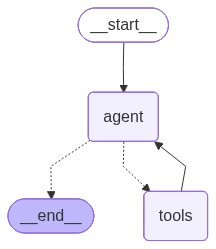

In [6]:
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic
from langchain.tools import tool
from langgraph.graph import START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

# Load ANTHROPIC_API_KEY from .env
load_dotenv(override=True)


# ── A2A Tool wrapper ───────────────────────────────────────────────────────────
# This @tool function is the bridge between the LangGraph orchestrator and
# the A2A agent. The LLM sees this as a normal tool. Internally it makes an
# HTTP POST to the A2A server — the LLM has no idea about HTTP or A2A.
@tool
async def ask_course_advisor(question: str) -> str:
    """
    Delegate a course-related question to the Course Advisor A2A agent.
    Use this tool for any question about:
    - available courses and their topics
    - recommended learning paths for beginners or specific goals
    - estimated study time or course duration
    - searching courses by topic, level, or keyword
    """
    async with httpx.AsyncClient() as client:
        response = await client.post(
            f"{A2A_SERVER_URL}/messages/send",
            json={
                "message": {
                    "role": "user",
                    "messageId": str(uuid.uuid4()),
                    "taskId": str(uuid.uuid4()),
                    "contextId": str(uuid.uuid4()),
                    "parts": [{"type": "text", "text": question}],
                }
            },
            timeout=10.0,
        )
        result = response.json()
        # Extract the text reply from the A2A response structure
        return result["result"]["parts"][0]["text"]


# ── LangGraph orchestrator ─────────────────────────────────────────────────────
# Claude Haiku as the orchestrator LLM — it decides when to call ask_course_advisor
llm = ChatAnthropic(model="claude-haiku-4-5-20251001", temperature=0)

# bind_tools() tells the LLM about the ask_course_advisor tool schema
# (name, description, argument types) so it knows when and how to call it
llm_with_tools = llm.bind_tools([ask_course_advisor])


async def call_model(state: MessagesState):
    # The LLM receives the full message history and returns either:
    # - an AIMessage with tool_calls (wants to call ask_course_advisor)
    # - an AIMessage with plain text (final answer ready)
    response = await llm_with_tools.ainvoke(state["messages"])
    return {"messages": [response]}


# Build the graph: START → agent ⇄ tools → END
builder = StateGraph(MessagesState)
builder.add_node("agent", call_model)

# ToolNode executes ask_course_advisor when the LLM produces a tool_call,
# which sends the HTTP request to the A2A server and returns the reply.
builder.add_node("tools", ToolNode([ask_course_advisor]))

builder.add_edge(START, "agent")

# tools_condition: routes to "tools" if the AIMessage has tool_calls,
# routes to END if the AIMessage is a plain text final answer
builder.add_conditional_edges("agent", tools_condition)

# After the A2A response comes back as a ToolMessage,
# send it to the agent so the LLM can write the final answer
builder.add_edge("tools", "agent")

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

## Step 7 – Run the Orchestrator

Ask the orchestrator a question. Watch it:
1. Decide to call `ask_course_advisor` (shows as `AIMessage` with `tool_calls`)
2. Delegate to the A2A server over HTTP (shows as `ToolMessage` with the raw reply)
3. Synthesise a final answer for the user (final `AIMessage`)

In [7]:
question = (
    "I want to learn about multi-agent systems and A2A protocol using LangGraph. "
    "What courses do you recommend? Also estimate how long it will take "
    "if I study 8 hours per week."
)

# ainvoke() runs the full ReAct loop:
#   Turn 1 — agent : LLM reads question, calls ask_course_advisor
#   Turn 2 — tools : ToolNode sends HTTP POST to A2A server, gets reply
#   Turn 3 — agent : LLM reads A2A reply, writes final answer
response = await graph.ainvoke({"messages": [("user", question)]})

print("─── Orchestrator Conversation ────────────────────────────────")
for message in response["messages"]:
    message.pretty_print()

─── Orchestrator Conversation ────────────────────────────────
================================ Human Message =================================

I want to learn about multi-agent systems and A2A protocol using LangGraph. What courses do you recommend? Also estimate how long it will take if I study 8 hours per week.
================================== Ai Message ==================================

[{'id': 'toolu_01LZucdoxwZ4EgKMYBFeFhgB', 'caller': {'type': 'direct'}, 'input': {'question': 'What courses are available for learning multi-agent systems and A2A protocol using LangGraph?'}, 'name': 'ask_course_advisor', 'type': 'tool_use'}, {'id': 'toolu_01Lm7oYK46T7AjkkrvfUFDuR', 'caller': {'type': 'direct'}, 'input': {'question': 'How long does it take to complete courses on multi-agent systems and LangGraph? What is the estimated study time?'}, 'name': 'ask_course_advisor', 'type': 'tool_use'}]
Tool Calls:
  ask_course_advisor (toolu_01LZucdoxwZ4EgKMYBFeFhgB)
 Call ID: toolu_01LZucdoxwZ4Eg

In [8]:
# Try a second question to see multi-turn orchestration
question2 = "I am completely new to AI. What is the best starting point and how many total hours will I need?"

response2 = await graph.ainvoke({"messages": [("user", question2)]})

print("─── Orchestrator Conversation ────────────────────────────────")
for message in response2["messages"]:
    message.pretty_print()

─── Orchestrator Conversation ────────────────────────────────
================================ Human Message =================================

I am completely new to AI. What is the best starting point and how many total hours will I need?
================================== Ai Message ==================================

[{'id': 'toolu_01Tr7UM46Rs6EEycMMJEpneA', 'caller': {'type': 'direct'}, 'input': {'question': 'I am completely new to AI. What is the best starting point for a beginner and how many total hours will I need to learn AI fundamentals?'}, 'name': 'ask_course_advisor', 'type': 'tool_use'}]
Tool Calls:
  ask_course_advisor (toolu_01Tr7UM46Rs6EEycMMJEpneA)
 Call ID: toolu_01Tr7UM46Rs6EEycMMJEpneA
  Args:
    question: I am completely new to AI. What is the best starting point for a beginner and how many total hours will I need to learn AI fundamentals?
================================= Tool Message =================================
Name: ask_course_advisor

For beginners I r

## Step 8 – Cleanup

Terminate the A2A server subprocess to free port 8765.  
Always run this before restarting the notebook or re-running Step 3.

In [9]:
server_process.terminate()
server_process.wait()
print(f"A2A server (PID {server_process.pid}) stopped. Port 8765 is now free.")

A2A server (PID 51246) stopped. Port 8765 is now free.


## Step 9 – Teaching Notes

---

### Why A2A exists

As AI systems grow, a single monolithic agent becomes hard to maintain and scale.
A2A enables **specialist agents** — each expert in one domain — to be composed into larger systems.
The orchestrator does not need to know anything about how each specialist agent works internally;
it only needs to know the agent's URL and its Agent Card.
This mirrors how microservices work in software architecture, but for AI agents.

---

### MCP vs A2A — when to use which

| Scenario | Use |
|---|---|
| Agent needs to call a database, API, or calculation function | **MCP** — the tool is a function, no reasoning needed |
| Agent needs to delegate a whole sub-task requiring judgment | **A2A** — the worker is a full agent with its own LLM/logic |
| Agent needs to compose multiple specialists | **A2A** — orchestrator sends tasks to specialists |
| Building a tool library others can share | **MCP** — tool servers are language-agnostic |
| Building a team of collaborating agents | **A2A** — each agent exposes its own Agent Card |

> In production systems you will often use **both**: the orchestrator delegates via A2A,
> and each specialist agent uses MCP tools internally.

---

### The A2A HTTP protocol — key endpoints

| Endpoint | Method | Purpose |
|---|---|---|
| `/.well-known/agent.json` | `GET` | Agent Card — capability discovery |
| `/messages/send` | `POST` | Send one message, get one response (request-response) |
| `/messages/stream` | `POST` | Send one message, get a streaming SSE response |
| `/tasks/{id}` | `GET` | Check the status of a long-running task |

This notebook implements only the first two — the minimum needed to build a working A2A system.

---

### A2A message anatomy

```
Message
  ├── role        : "user" | "agent"
  ├── messageId   : unique ID for this message
  ├── taskId      : groups messages into one logical task
  ├── contextId   : groups tasks into one session
  └── parts       : list of Part objects
        └── Part
              ├── type : "text" | "file" | "data"
              └── text : the actual content (for type="text")
```

Using `taskId` and `contextId` lets you build **multi-turn** conversations:
all messages with the same `contextId` belong to the same session.

---

### The Agent Card anatomy

```
AgentCard
  ├── name              : human-readable agent name
  ├── description       : what the agent does (the LLM reads this)
  ├── url               : base URL for all A2A endpoints
  ├── version           : semantic version string
  ├── defaultInputModes : ["text", "file", "data"]
  ├── defaultOutputModes: ["text", "file", "data"]
  ├── capabilities
  │     ├── streaming         : true/false (supports /messages/stream)
  │     └── pushNotifications : true/false (agent can call back a webhook)
  └── skills            : list of Skill
        └── Skill
              ├── id          : machine-readable skill identifier
              ├── name        : human-readable skill name
              ├── description : what this skill does (the LLM reads this)
              ├── inputModes  : what input types this skill accepts
              ├── outputModes : what output types this skill returns
              └── examples    : sample inputs (helps the LLM decide when to call it)
```

---

### The full flow, step by step

```
1. Client fetches GET /.well-known/agent.json
      → learns the agent's name, skills, and capabilities

2. User asks the orchestrator a question
      → HumanMessage added to LangGraph state

3. agent node: LLM reads the question + tool schema
      → decides to call ask_course_advisor
      → returns AIMessage with tool_calls

4. tools node: ToolNode runs ask_course_advisor
      → builds an A2A message (role, messageId, parts)
      → sends HTTP POST /messages/send to the A2A server
      → A2A server's build_reply() processes the text
      → A2A server returns a response message
      → ToolNode extracts the text from result.parts[0].text
      → appends a ToolMessage to LangGraph state

5. agent node: LLM reads the original question + ToolMessage
      → no more tool_calls needed
      → returns final AIMessage with natural-language answer

6. tools_condition: no tool_calls → routes to END

7. User receives the final answer
```

---

### Classroom extension ideas

| Idea | What to change |
|---|---|
| Add a second A2A agent | Create a `a2a_quiz_agent_server.py`, add a second `@tool` wrapper, give both tools to the LLM |
| Make the worker agent use an LLM | Replace `build_reply()` with a `ChatAnthropic` call inside the FastAPI endpoint |
| Support streaming | Add `POST /messages/stream` with `StreamingResponse` and SSE |
| Use `taskId` for multi-turn | Store task history in a dict keyed by `taskId`, append new messages each turn |
| Deploy as a real service | Replace `localhost:8765` with a cloud URL; update the Agent Card's `url` field |